In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

### 1. Setting up Configurations

In [2]:
RAW_DATA_PATH = Path('../../data/raw/Telco-Customer-Churn.csv')
PROCESSED_DATA_PATH = Path('../../data/processed')
ARTIFACTS_DIR = Path('../../artifacts')
FIGURE_DIR = Path('../../artifacts/figures')

### 2. Load Data

In [3]:
df = pd.read_csv(RAW_DATA_PATH)

In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Bivariate Analys

In this section, the code is run to analyze the effect of each feature on the churn target variable.

In [24]:
"""
    These two function act to visualize bivariate analysis against target feature Churn
        - Categorical feature : def bivariate_analysis(compare_feature)
        - Numerical feature : def bivariate_analysis_numerical(compare_feature):
"""

def bivariate_analysis(compare_feature):
    analyzed_table= pd.crosstab(df[compare_feature], df['Churn'], normalize='index') * 100
    analyzed_table.plot(kind='bar', stacked=False, color=['steelblue','tomato'])
    plt.title('Churn rate by ' + compare_feature)
    plt.xlabel(compare_feature)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.legend(['No churn','Churn'])
    plt.savefig(FIGURE_DIR / f"bivariate_{compare_feature}_vs_Churn.png")

def bivariate_analysis_numerical(compare_feature):
    sns.boxplot(x="Churn", y=compare_feature, data=df, hue='Churn', legend=False)
    plt.title('Churn rate by ' + compare_feature)
    plt.xlabel('Churn')
    plt.ylabel(compare_feature)
    plt.xticks(rotation=0)
    plt.savefig(FIGURE_DIR / f"bivariate_{compare_feature}_vs_Churn.png")


#### 3.1 Contract vs Churn

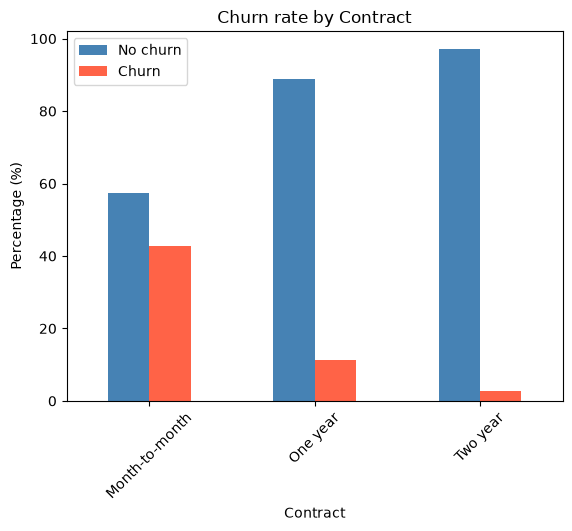

In [6]:
bivariate_analysis('Contract')

#### Contract vs Churn
 
**Observation**
Month-to-month contracts have a remarkably high churn rate (approximately ~42%). In stark contrast, customers on Two-year contracts show an exceptionally low churn rate (~2-3%).
 
**Statistical Interpretation**
There is a severe, statistically significant relationship between the length of the contract term and churn likelihood. Shorter commitment periods correlate strongly with higher attrition.
 
**Business Insight**
Customers who are not locked into long-term agreements have the flexibility to leave for competitors when faced with a minor inconvenience or a better promotional offer. Long-term contracts successfully create friction for churn and ensure customer stickiness.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Strong |
| Risk Level | High |
 
**Key Takeaway:** Month-to-month contracts are the most critical risk factor for churn; incentivizing longer commitments is essential for retention.

### Summery
- Month to Month has on heights churn rate approximately 40% of customers on M2M contract
- The lowest churn rate has on Two year customes as approximately 2% of 2Y on contract
- this is high-priority feature

#### 3.2 Gender vs Churn

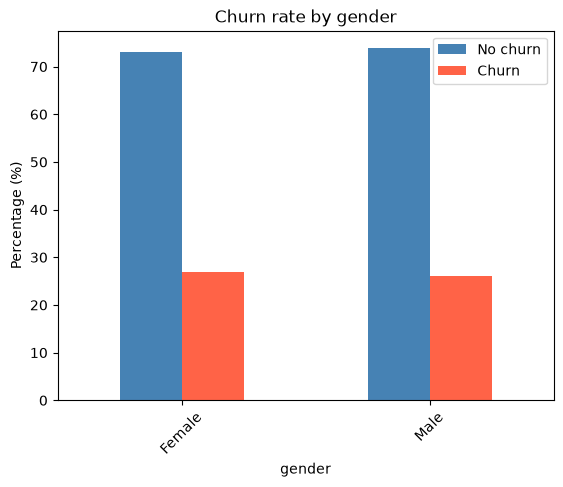

In [7]:
bivariate_analysis('gender')


#### Gender vs Churn
 
**Observation**
The churn rate is nearly identical when comparing Male and Female customers, hovering around 26-27% for both groups.
 
**Statistical Interpretation**
Gender is uniformly distributed across the churned and retained customer bases. It holds almost zero predictive power for determining whether a customer will leave.
 
**Business Insight**
Targeted retention campaigns or pricing strategies based on gender will likely be ineffective. Customer retention efforts should be gender-agnostic.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Weak |
| Risk Level | Low |
 
**Key Takeaway:** Gender is not a differentiating factor for predicting or managing customer churn.

### Summery
- Churn rate nearly identical across groups (27% vs 26%)
- Decision: weak feature, monitor importance score, candidate for removal

### 3.3 SeniorCitizen vs Churn

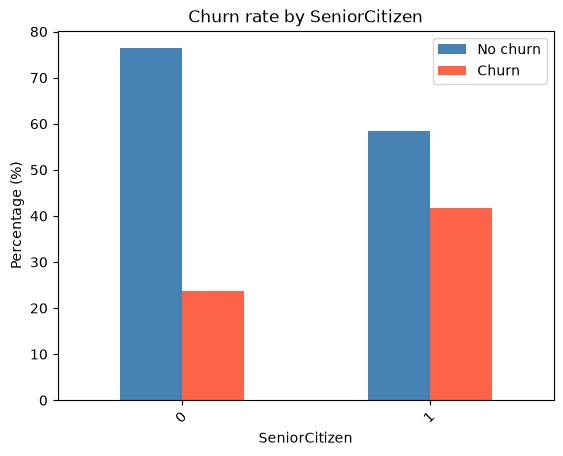

In [8]:
bivariate_analysis('SeniorCitizen')

#### SeniorCitizen vs Churn
 
**Observation**
Senior citizens represent a smaller subset of the overall customer base but exhibit a significantly higher churn rate compared to non-senior citizens (roughly 41% vs. 23%).
 
**Statistical Interpretation**
Being a senior citizen is positively correlated with a higher probability of churning. While non-seniors make up the bulk of the data, the proportion of seniors churning is disproportionately large.
 
**Business Insight**
Seniors may be experiencing specific pain points, such as difficulty navigating technical support, confusion over complex billing structures, or fixed-income constraints that make them more sensitive to price hikes.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Moderate |
| Risk Level | Medium |
 
**Key Takeaway:** Senior citizens are at elevated risk; specialized, simplified support or tailored "senior-friendly" plans might help retain them.

#### Summery 
- The diagram shows there are more non senior citizeon count than senior citizon
- And more senior citizon likely to churn , as 80% of senior citizon has churned


### 3.3 Partner vs Churn

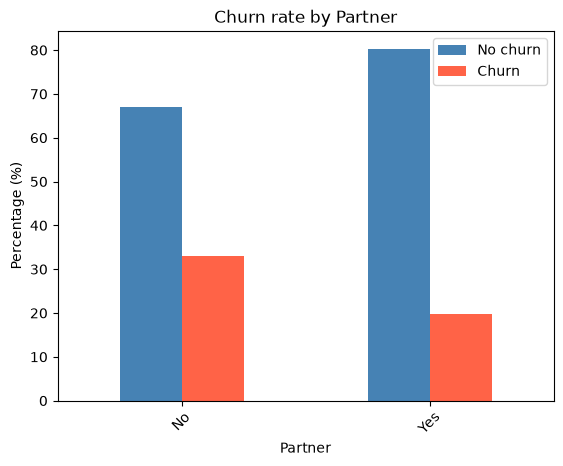

In [9]:
bivariate_analysis('Partner')

#### Partner vs Churn
 
**Observation**
Customers without a partner have a noticeably higher churn rate (~33%) compared to customers with a partner (~20%).
 
**Statistical Interpretation**
Having a partner indicates a more stable household situation, which negatively correlates with churn. Single customers are more mobile and prone to changing providers.
 
**Business Insight**
Households with partners may have more complex, deeply integrated telecom needs (e.g., shared data plans, multiple lines), making it harder to switch providers. Single users are more agile and price-sensitive.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Moderate |
| Risk Level | Medium |
 
**Key Takeaway:** Single users churn more frequently; promoting family or shared household plans could improve retention by increasing switching costs.

#### Summery
- No partner customer has heighst churn rate that Partner customer approximately 13% of presentage
- Partner churn rate 20% | no partner churn rate 33%

#### 3.4 Dependents vs Churn

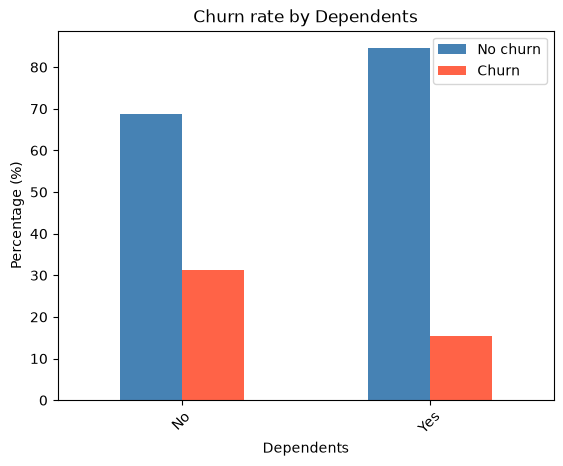

In [10]:
bivariate_analysis('Dependents')

#### Dependents vs Churn
 
**Observation**
Customers without dependents churn at a substantially higher rate (~31%) than customers with dependents (~15%).
 
**Statistical Interpretation**
Similar to the Partner feature, the presence of dependents acts as a stabilizing factor. Customers with dependents are half as likely to churn.
 
**Business Insight**
Families with children (dependents) likely prioritize stability and are less willing to deal with the disruption of changing service providers. They may also be on bundled family plans that are difficult to untangle.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Moderate |
| Risk Level | Medium |
 
**Key Takeaway:** Customers without dependents are highly flight-prone. Bundled family packages are highly effective at building loyalty.

### 3.5 PhoneService vs Churn

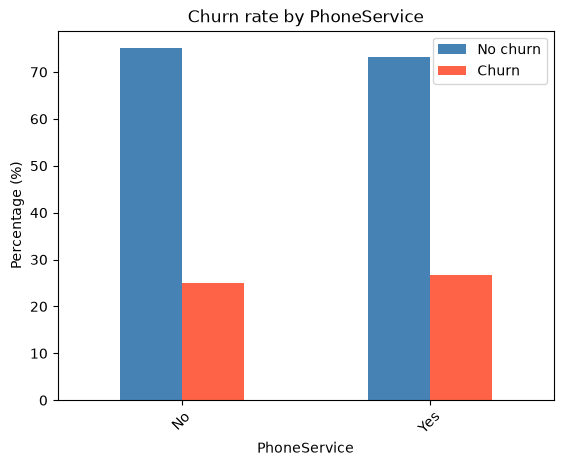

In [11]:
bivariate_analysis('PhoneService')

#### PhoneService vs Churn
 
**Observation**
Churn rates are largely similar whether a customer has Phone Service (~27%) or not (~25%).
 
**Statistical Interpretation**
The presence or absence of phone service alone does not significantly alter the probability of a customer churning.
 
**Business Insight**
Phone service is largely considered a basic utility and does not serve as a competitive differentiator that drives or prevents customer attrition on its own.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Weak |
| Risk Level | Low |
 
**Key Takeaway:** Having a phone service is a neutral factor in determining churn risk.

### 3.6 MultipleLines vs Churn

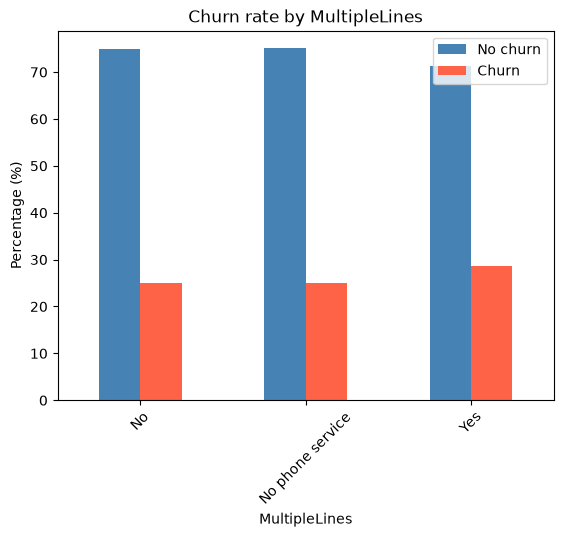

In [12]:
bivariate_analysis('MultipleLines')

#### MultipleLines vs Churn
 
**Observation**
There is only a marginal difference in churn between customers with multiple lines (~28%) and those with a single line (~25%).
 
**Statistical Interpretation**
While adding multiple lines slightly increases the churn rate, the difference is not substantial enough to be a primary predictive driver.
 
**Business Insight**
Customers with multiple lines might have higher overall bills, which could cause slight price sensitivity, but it is not a major area of concern on its own.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Weak |
| Risk Level | Low |
 
**Key Takeaway:** Multiple lines have a negligible impact on a customer's decision to leave.

### 3.7 InternetService vs Churn

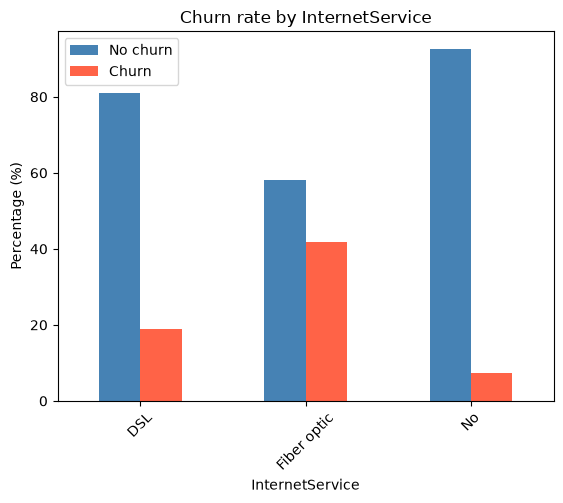

In [13]:
bivariate_analysis('InternetService')

#### InternetService vs Churn
 
**Observation**
Customers utilizing "Fiber optic" internet have a dramatically high churn rate (~42%), whereas "DSL" users churn much less (~19%). Customers with "No internet service" have the lowest churn rate of all (~7%).
 
**Statistical Interpretation**
Internet Service Type is a massive differentiator for churn. Fiber optic service is highly correlated with a customer leaving, which is an anomaly given that fiber is supposed to be a premium, high-speed product.
 
**Business Insight**
The high churn among Fiber Optic customers points to a serious product or service issue. It could be due to fierce competition offering better fiber pricing, poor network reliability (outages), or unmet expectations regarding speed versus cost.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Strong |
| Risk Level | High |
 
**Key Takeaway:** Fiber Optic customers are highly dissatisfied and churning rapidly; immediate investigation into fiber service quality and competitor pricing is required.

### 3.8 OnlineSecurity vs Churn

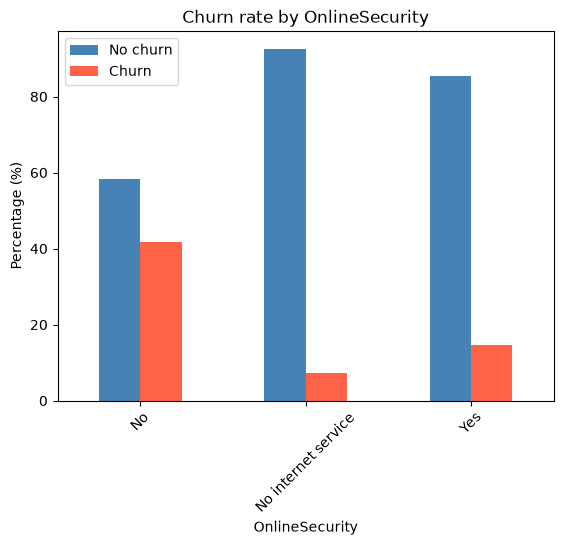

In [14]:
bivariate_analysis('OnlineSecurity')

#### OnlineSecurity vs Churn
 
**Observation**
Customers who do not have Online Security churn at a massive rate (~42%), compared to those who do have it (~15%).
 
**Statistical Interpretation**
Lack of Online Security is a strong predictor of churn. Subscribing to this add-on heavily depresses the churn rate.
 
**Business Insight**
Online Security acts as a "sticky" feature. Customers who invest in security feel more protected and integrated into the ecosystem, making them less likely to leave. Conversely, those without it may be on bare-bones plans and highly price-sensitive.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Strong |
| Risk Level | High |
 
**Key Takeaway:** Customers without online security are highly vulnerable to churn. Bundling security features for free or at a discount could drastically improve retention.

### 3.8 OnlineBackup vs Churn

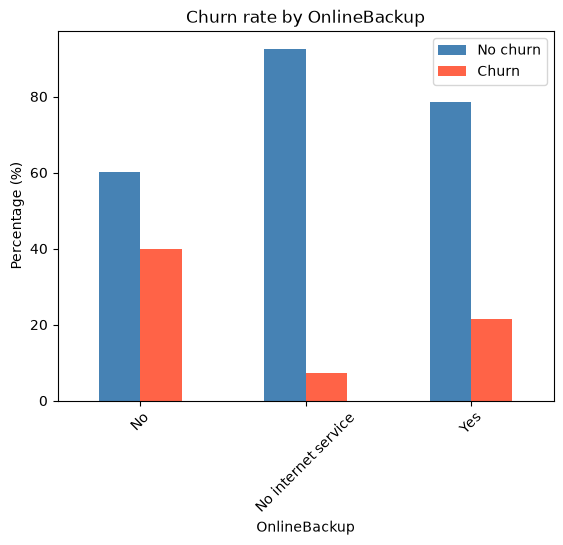

In [15]:
bivariate_analysis('OnlineBackup')

#### OnlineBackup vs Churn
 
**Observation**
Similar to Online Security, customers lacking Online Backup show much higher churn rates (~40%) than those who subscribe to it (~21%).
 
**Statistical Interpretation**
The absence of value-added technical services correlates strongly with customer attrition.
 
**Business Insight**
When customers store their data with the telecom provider's backup service, the "switching cost" (the effort required to move to a new provider) increases significantly.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Moderate to Strong |
| Risk Level | High |
 
**Key Takeaway:** Online backup creates a lock-in effect; customers without it can easily walk away.

### 3.9 DeviceProtection vs Churn

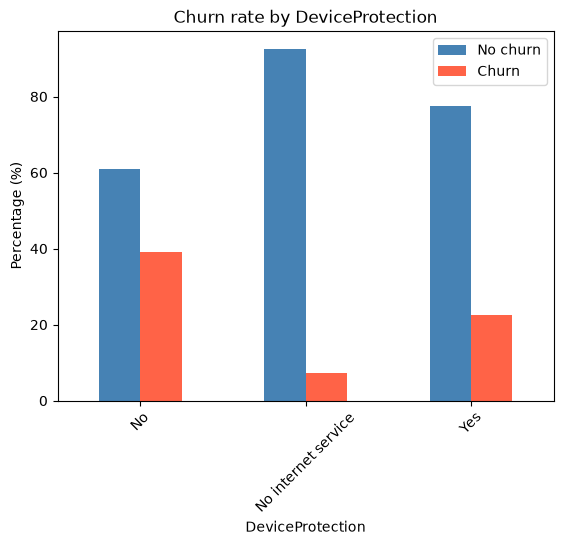

In [16]:
bivariate_analysis('DeviceProtection')

#### DeviceProtection vs Churn
 
**Observation**
Customers without Device Protection churn more (~39%) than those with the protection plan (~22%).
 
**Statistical Interpretation**
There is a clear negative correlation between having device protection and churning.
 
**Business Insight**
Customers paying for device protection likely own expensive, premium devices (e.g., flagship smartphones) and value peace of mind. These customers are more invested in the telecom provider's ecosystem.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Moderate |
| Risk Level | Medium |
 
**Key Takeaway:** Selling device insurance improves customer stickiness.

### 3.10 12: TechSupport vs Churn

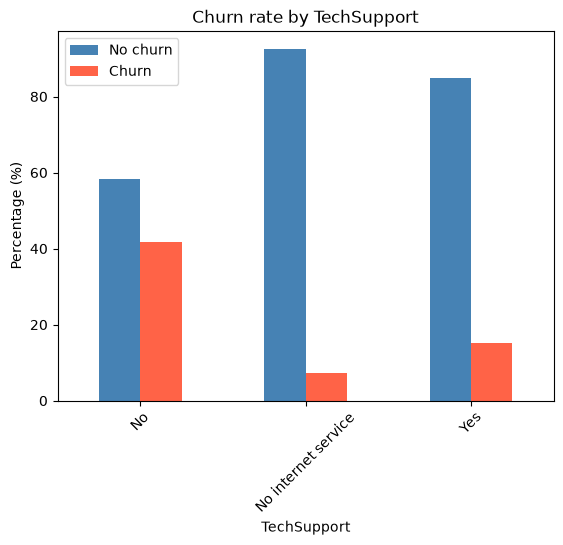

In [17]:
bivariate_analysis('TechSupport')

#### TechSupport vs Churn
 
**Observation**
Customers who do not use or subscribe to Tech Support have a severe churn rate (~41%), while those with Tech Support rarely churn (~15%).
 
**Statistical Interpretation**
Tech support is a major defining feature dividing churners from non-churners.
 
**Business Insight**
Customers without tech support may get easily frustrated when they face technical difficulties and simply cancel their service. Those with tech support get their issues resolved quickly, leading to higher satisfaction and retention.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Strong |
| Risk Level | High |
 
**Key Takeaway:** Accessible tech support is crucial for retention; lack of it is a major driver of customer loss.

### 3.11 StreamingTV & StreamingMovies vs Churn

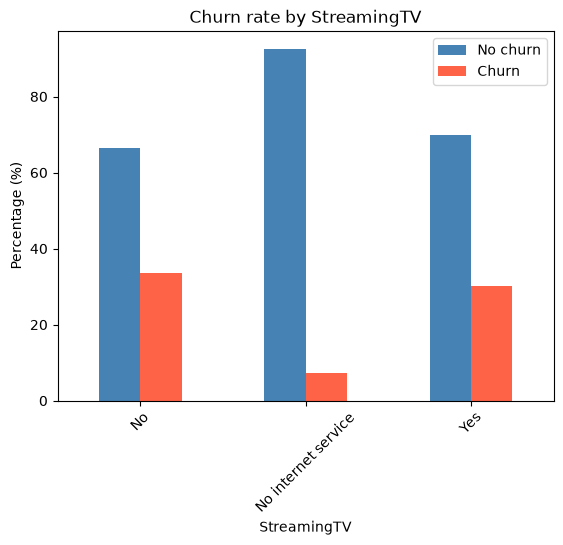

In [18]:
bivariate_analysis('StreamingTV')

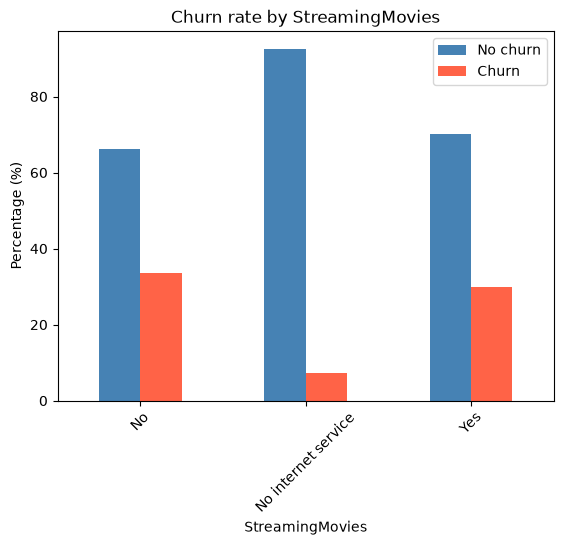

In [19]:
bivariate_analysis('StreamingMovies')

#### StreamingTV & StreamingMovies vs Churn
 
**Observation**
Whether a customer streams TV or Movies has a relatively minimal impact on churn. Both "Yes" and "No" categories for these features show moderate churn rates (in the low-to-mid 30% range for internet users).
 
**Statistical Interpretation**
Entertainment add-ons like Streaming TV and Movies are not strong discriminators for churn compared to utility/security add-ons.
 
**Business Insight**
While streaming services are nice-to-have revenue generators, they do not create the same structural "lock-in" effect as tech support or security.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Weak |
| Risk Level | Low |
 
**Key Takeaway:** Streaming features generate revenue but do not significantly protect against churn.

### 3.12 PaperlessBilling vs Churn

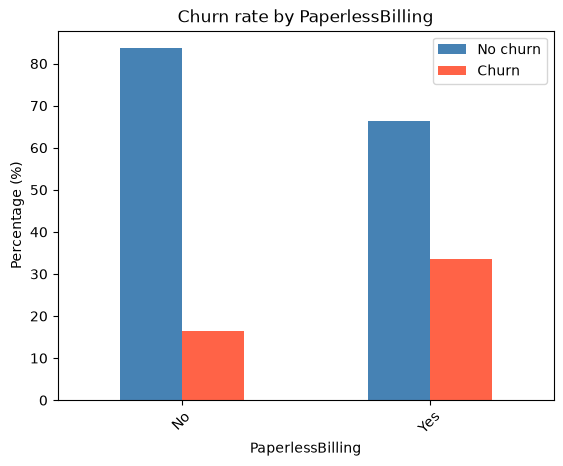

In [20]:
bivariate_analysis('PaperlessBilling')

#### PaperlessBilling vs Churn

**Observation**
Customers who opt for Paperless Billing have a notably higher churn rate (~33%) compared to those receiving traditional paper bills (~16%).
 
**Statistical Interpretation**
There is a surprising positive correlation between modern, paperless billing and customer churn.
 
**Business Insight**
Customers using paperless billing are likely more tech-savvy, digitally engaged, and aware of their monthly expenses through emails or apps. This makes them more agile and capable of easily finding and switching to a competitor's digital platform. Paper bill recipients might be older or prefer the status quo.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Moderate |
| Risk Level | Medium |
 
**Key Takeaway:** Digitally engaged (paperless) customers are more likely to comparison shop and switch providers.
 

### 3.13 PaymentMethod vs Churn

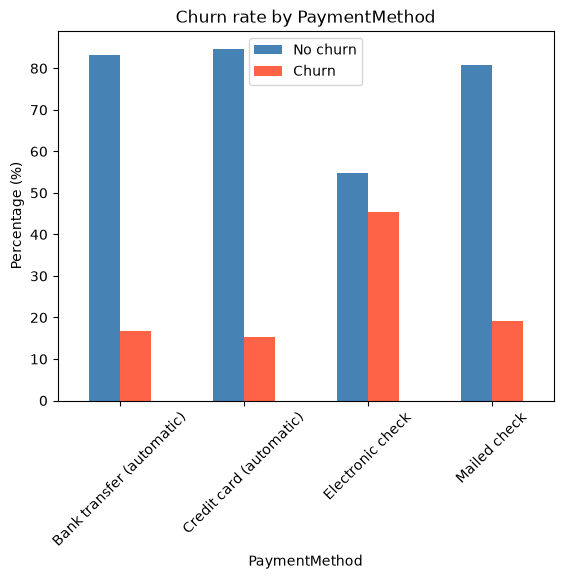

In [21]:
bivariate_analysis('PaymentMethod')

#### PaymentMethod vs Churn

**Observation**
"Electronic check" stands out drastically with an exceptionally high churn rate (~45%). All other payment methods (Mailed check, Bank transfer, Credit card) have low and similar churn rates (~15-19%).
 
**Statistical Interpretation**
The use of Electronic checks is a massive statistical anomaly and a primary indicator of churn risk.
 
**Business Insight**
Electronic checks often require manual initiation each month, forcing the customer to confront their bill actively. This regular, manual payment process acts as a recurring reminder of the cost, increasing price sensitivity. Automatic payments (credit cards/bank transfers) are "out of sight, out of mind," leading to better retention.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Strong |
| Risk Level | High |
 
**Key Takeaway:** Electronic check users are extremely high-risk. Pushing customers toward automated credit card or bank transfer billing is imperative.

### 3.14 Tenure vs Churn

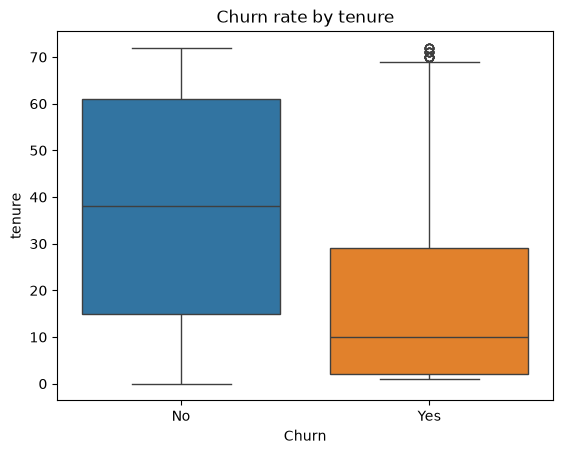

In [25]:
bivariate_analysis_numerical('tenure')

#### Tenure vs Churn
 
**Observation**
The boxplot/KDE for tenure shows that churning customers have a significantly lower median tenure (usually around 10 months) compared to retained customers (who skew heavily towards 35-40+ months).
 
**Statistical Interpretation**
Tenure is inversely proportional to churn. The risk of churn is exponentially higher in the first 12 months of the customer lifecycle.
 
**Business Insight**
If a customer survives their first year, their likelihood of leaving drops drastically. The onboarding period and the end of the initial 1-year promotional contract are critical danger zones.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Strong |
| Risk Level | High (Specifically for New Customers) |
 
**Key Takeaway:** Customer loyalty is built in the first year. First-year retention programs are critical.

### 3.14 MonthlyCharges vs Churn

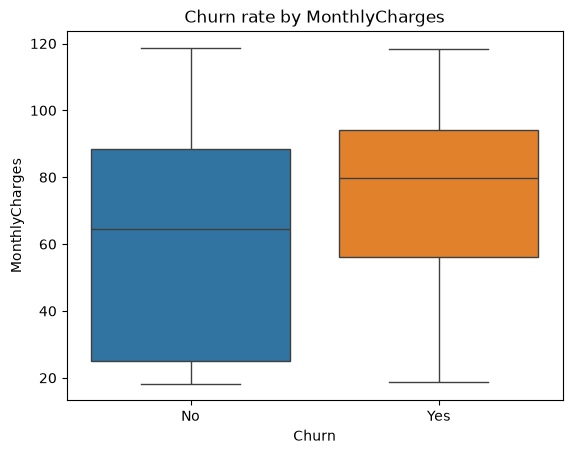

In [29]:
bivariate_analysis_numerical('MonthlyCharges')


#### MonthlyCharges vs Churn (Numerical)
 
**Observation**
Churning customers tend to have higher overall Monthly Charges (skewing towards $70-$100) compared to retained customers, who have a wider spread including many low-cost plans.
 
**Statistical Interpretation**
Higher monthly costs correlate with higher churn probability, confirming high price sensitivity among the customer base.
 
**Business Insight**
As the bill increases—likely due to upselling premium features like Fiber Optic internet—customers become highly sensitive to value. If the premium price isn't matched by premium quality, they leave.
 
**Churn Impact Assessment**
| Metric | Value |
|---|---|
| Strength of Relationship | Moderate to Strong |
| Risk Level | Medium to High |
 
**Key Takeaway:** High-value (high MRR) customers are actually at higher risk of leaving due to cost sensitivity and high expectations.